# Hotel Booking Cancellation — EDA & Modeling

**Project:** Classical ML Pipeline  
**Dataset:** Hotel Booking Demand (Kaggle)  
**Author:** Sai  
**GitHub:** https://github.com/karthi9407/hotel-booking-cancellation

---

## Problem Framing

**Prediction task:** Binary classification — will this booking be cancelled?  
**Prediction point:** The moment a booking is confirmed. We can only use information available at that instant.  
**Target:** `is_canceled` (1 = cancelled, 0 = not cancelled)  
**Implication:** Any feature generated after booking confirmation is leakage and must be dropped.

## Session 1 — Data Load & First Look

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, roc_curve
)
from xgboost import XGBClassifier

%matplotlib inline
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('../data/raw/hotel_bookings.csv')
print(f'Shape: {df.shape}')

Shape: (119390, 32)


In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.00,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.10,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.40,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.00,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


### Session 1 — Observations

1. The data covers arrivals between 2015 and 2017
2. Some fields are binary flags (is_canceled, is_repeated_guest) stored as int64
3. There are only two hotel types: City Hotel and Resort Hotel
4. Company and agent columns have substantial missing values — this is signal, not noise
5. The days_in_waiting_list column has extreme outliers (max 391 days)

---
## Session 2 — EDA Part 1: Univariate Analysis

In [6]:
# Missing data audit
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df[missing_df['missing'] > 0].sort_values('pct', ascending=False)

,missing,pct
company,112593,94.30
agent,16340,13.70
country,488,0.40
children,4,0.00


In [7]:
# Class balance
print(df['is_canceled'].value_counts())
print(df['is_canceled'].value_counts(normalize=True).round(3))

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0   0.63
1   0.37
Name: proportion, dtype: float64


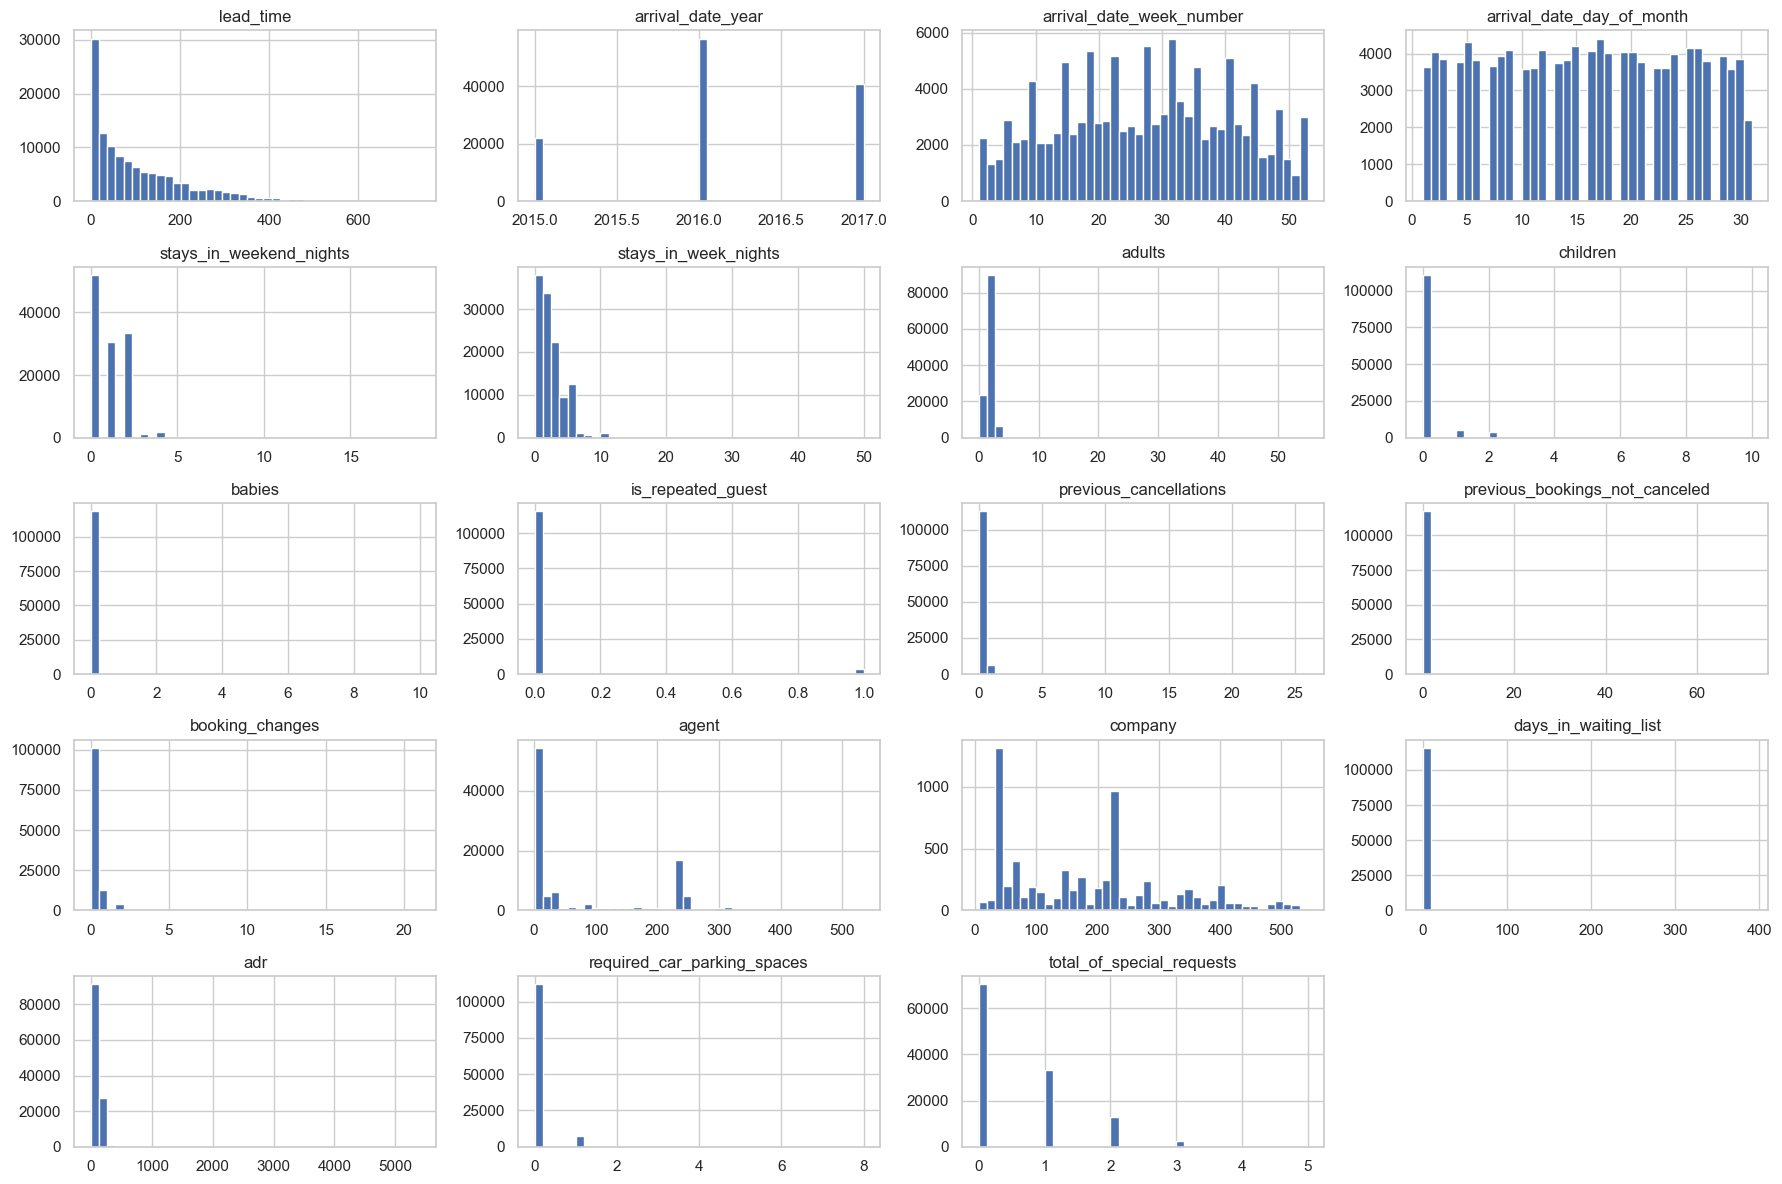

In [8]:
# Numeric distributions
numeric_cols = df.select_dtypes(include='number').columns.drop('is_canceled')
df[numeric_cols].hist(figsize=(18, 12), bins=40)
plt.tight_layout()
plt.show()

/var/folders/j5/gkknqv694q7029z0449cbfgw0000gn/T/ipykernel_37471/3784355859.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


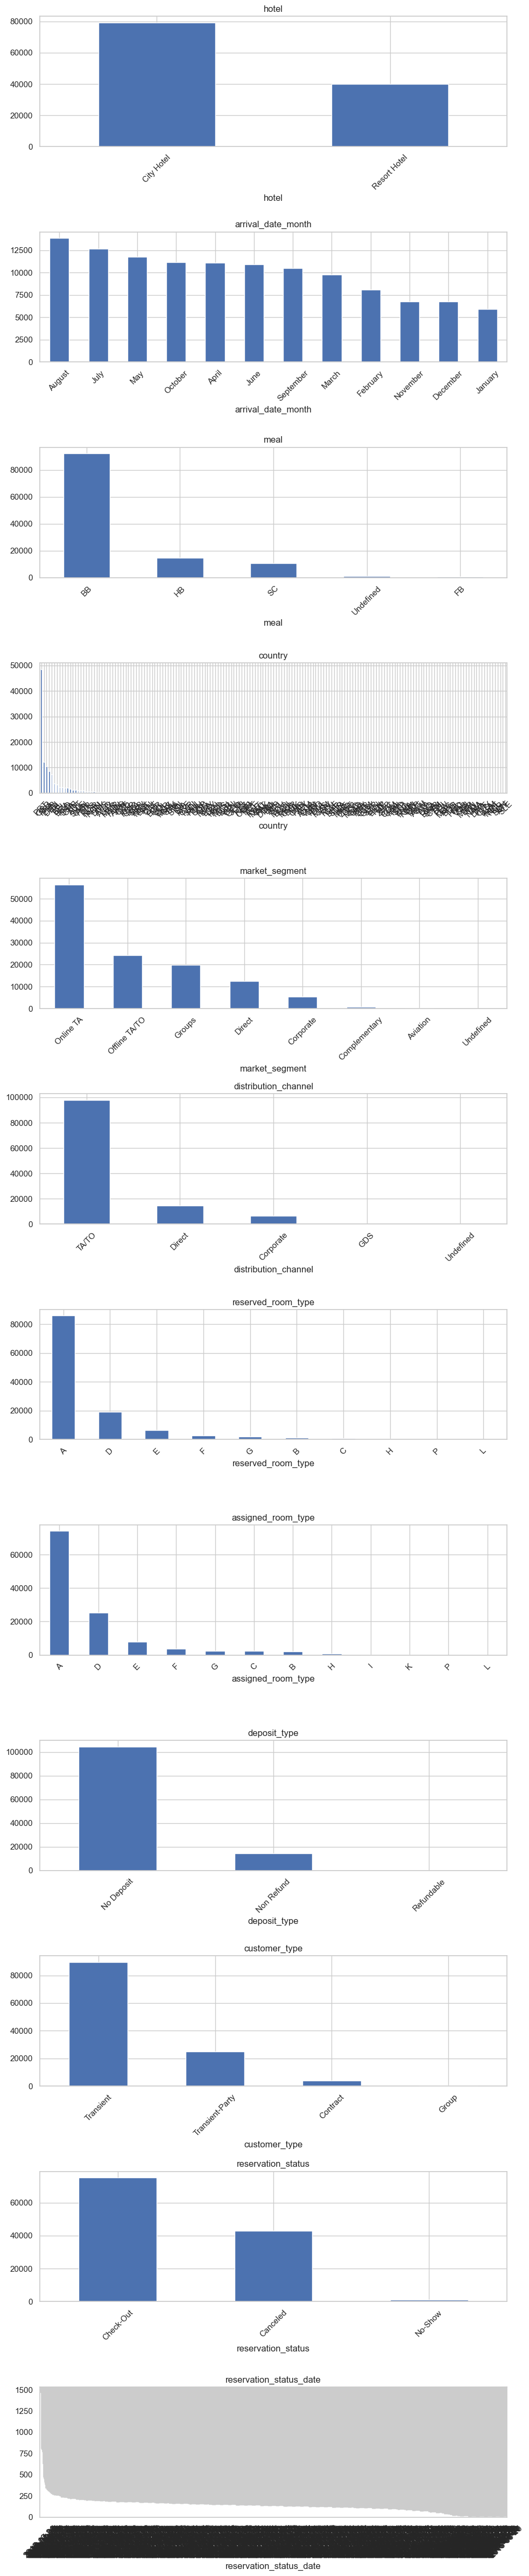

In [9]:
# Categorical distributions
cat_cols = df.select_dtypes(include='object').columns
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 4 * len(cat_cols)))
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], title=col)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Suspicious values
print("adr negatives:", (df['adr'] < 0).sum())
print("lead_time > 365:", (df['lead_time'] > 365).sum())
print("adults == 0:", (df['adults'] == 0).sum())
print("stays both 0:", ((df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0)).sum())

# Inspect adult=0 rows
df[df['adults'] == 0][['adults', 'children', 'babies', 'is_canceled']].head(10)

adr negatives: 1
lead_time > 365: 3148
adults == 0: 403
stays both 0: 715


,adults,children,babies,is_canceled
2224,0,0.00,0,0
2409,0,0.00,0,0
3181,0,0.00,0,0
3684,0,0.00,0,0
3708,0,0.00,0,0
4127,0,0.00,0,1
9376,0,0.00,0,1
31765,0,0.00,0,0
32029,0,0.00,0,0
32827,0,0.00,0,0


### Session 2 — Summary

The dataset covers 119,390 hotel bookings across two properties (Resort and City Hotel) from 2015–2017. 37% of bookings were cancelled, making accuracy a misleading metric. Four columns have missing values: company (94%) and agent (14%) are missing by design — those are direct bookings — and their missingness is itself a signal worth encoding as a feature. A handful of suspicious records exist: one negative ADR, 715 zero-night stays, and 403 adult-free bookings, all of which will be dropped before modeling. Two columns — deposit_type and distribution_channel — are heavily skewed toward a single value but may still carry signal in their minority categories.

---
## Session 3 — EDA Part 2: Bivariate Analysis

In [11]:
def cancellation_rate(df, col):
    return (df.groupby(col)['is_canceled']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'cancel_rate', 'count': 'n'})
              .sort_values('cancel_rate', ascending=False)
              .round(3))

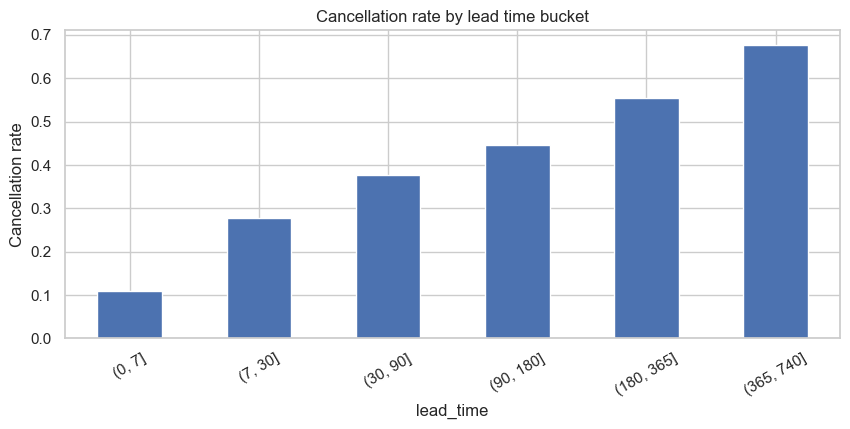

In [12]:
# Lead time vs cancellation
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby(pd.cut(df['lead_time'], bins=[0,7,30,90,180,365,740]))['is_canceled'].mean().plot(kind='bar', ax=ax)
ax.set_title('Cancellation rate by lead time bucket')
ax.set_ylabel('Cancellation rate')
plt.xticks(rotation=30)
plt.show()

In [13]:
# Key categoricals
for col in ['hotel', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type']:
    print(f"\n--- {col} ---")
    print(cancellation_rate(df, col))


--- hotel ---
              cancel_rate      n
hotel                           
City Hotel           0.42  79330
Resort Hotel         0.28  40060

--- market_segment ---
                cancel_rate      n
market_segment                    
Undefined              1.00      2
Groups                 0.61  19811
Online TA              0.37  56477
Offline TA/TO          0.34  24219
Aviation               0.22    237
Corporate              0.19   5295
Direct                 0.15  12606
Complementary          0.13    743

--- distribution_channel ---
                      cancel_rate      n
distribution_channel                    
Undefined                    0.80      5
TA/TO                        0.41  97870
Corporate                    0.22   6677
GDS                          0.19    193
Direct                       0.17  14645

--- deposit_type ---
              cancel_rate       n
deposit_type                     
Non Refund           0.99   14587
No Deposit           0.28  104641
Refu

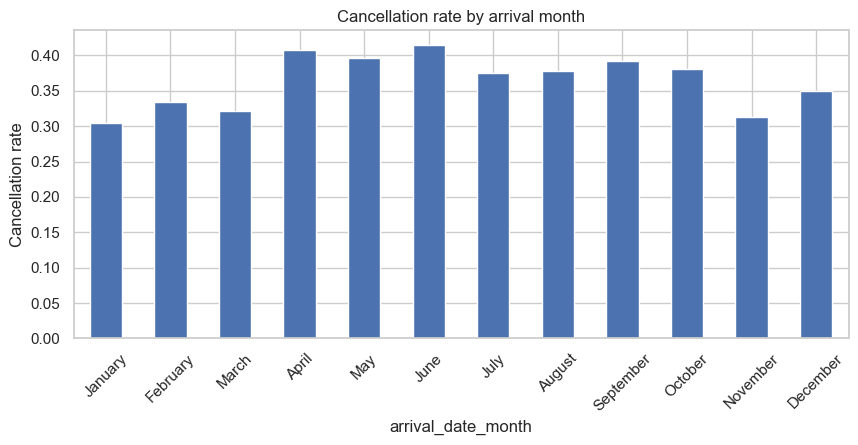

In [14]:
# Month seasonality
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
rates = df.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order)
rates.plot(kind='bar', figsize=(10, 4), title='Cancellation rate by arrival month')
plt.ylabel('Cancellation rate')
plt.xticks(rotation=45)
plt.show()

In [15]:
# Repeated guest and previous behaviour
for col in ['is_repeated_guest', 'previous_cancellations', 'total_of_special_requests']:
    print(f"\n--- {col} ---")
    print(cancellation_rate(df, col))


--- is_repeated_guest ---
                   cancel_rate       n
is_repeated_guest                     
0                         0.38  115580
1                         0.14    3810

--- previous_cancellations ---
                        cancel_rate       n
previous_cancellations                     
14                             1.00      14
19                             1.00      19
21                             1.00       1
24                             1.00      48
25                             1.00      25
26                             1.00      26
1                              0.94    6051
13                             0.92      12
0                              0.34  112906
2                              0.33     116
6                              0.32      22
3                              0.31      65
11                             0.29      35
4                              0.23      31
5                              0.10      19

--- total_of_special_requests ---
  

In [16]:
# Room type mismatch — NOTE: this is leakage (assigned at check-in, not at booking)
df['room_mismatch'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)
print(cancellation_rate(df, 'room_mismatch'))

               cancel_rate       n
room_mismatch                     
0                     0.42  104473
1                     0.05   14917


In [17]:
# Leakage audit — columns to drop before modeling
leakage_cols = [
    'reservation_status',       # directly encodes the outcome
    'reservation_status_date',  # set after cancellation
    'assigned_room_type',       # known only at check-in
]
print("Remaining columns after leakage drop:")
print([c for c in df.columns if c not in leakage_cols])

Remaining columns after leakage drop:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'room_mismatch']


### Session 3 — Summary

Key findings: longer lead time strongly predicts cancellation; deposit_type Non Refund has ~99% cancellation rate (counterintuitive — driven by OTA bulk bookings); room_mismatch appears predictive but is leakage (assigned room is only known at check-in). Three columns dropped before modeling: reservation_status, reservation_status_date, and assigned_room_type.

---
## Session 4 — Train/Val/Test Split & Baseline

In [18]:
# Drop leakage and clean suspicious rows
leakage_cols = ['reservation_status', 'reservation_status_date', 'assigned_room_type']
df_clean = df.drop(columns=leakage_cols)

df_clean = df_clean[~((df_clean['stays_in_weekend_nights'] == 0) &
                       (df_clean['stays_in_week_nights'] == 0))]
df_clean = df_clean[df_clean['adults'] > 0]
df_clean = df_clean[df_clean['adr'] >= 0]

print(f"Rows after cleaning: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

Rows after cleaning: 118341 (dropped 1049)


In [19]:
# Time-based split — train: 2015-2016, val: Jan-May 2017, test: Jun-Aug 2017
df_clean['arrival_date'] = pd.to_datetime(
    df_clean['arrival_date_year'].astype(str) + '-' +
    df_clean['arrival_date_month'] + '-' +
    df_clean['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)

train = df_clean[df_clean['arrival_date'] < '2017-01-01']
val   = df_clean[(df_clean['arrival_date'] >= '2017-01-01') &
                 (df_clean['arrival_date'] < '2017-06-01')]
test  = df_clean[df_clean['arrival_date'] >= '2017-06-01']

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
print(f"Train cancel rate: {train['is_canceled'].mean():.3f}")
print(f"Val cancel rate:   {val['is_canceled'].mean():.3f}")
print(f"Test cancel rate:  {test['is_canceled'].mean():.3f}")

Train: 77895 | Val: 24623 | Test: 15823
Train cancel rate: 0.365
Val cancel rate:   0.385
Test cancel rate:  0.394


In [20]:
# Baseline features (numeric only)
target = 'is_canceled'
baseline_features = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'is_repeated_guest', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes',
    'days_in_waiting_list', 'adr', 'total_of_special_requests'
]

X_train_b = train[baseline_features]
y_train_b = train[target]
X_val_b   = val[baseline_features]
y_val_b   = val[target]

In [21]:
# Baseline 1: majority class
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_b, y_train_b)
y_pred_dummy = dummy.predict(X_val_b)

print("=== Baseline: Majority Class ===")
print(classification_report(y_val_b, y_pred_dummy))
print(f"ROC AUC: {roc_auc_score(y_val_b, dummy.predict_proba(X_val_b)[:,1]):.3f}")

=== Baseline: Majority Class ===
              precision    recall  f1-score   support

           0       0.62      1.00      0.76     15152
           1       0.00      0.00      0.00      9471

    accuracy                           0.62     24623
   macro avg       0.31      0.50      0.38     24623
weighted avg       0.38      0.62      0.47     24623

ROC AUC: 0.500


/opt/miniconda3/envs/ml-pipeline/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/ml-pipeline/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/ml-pipeline/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [22]:
# Baseline 2: logistic regression (numeric only)
lr_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

lr_baseline.fit(X_train_b, y_train_b)
y_pred_lr = lr_baseline.predict(X_val_b)
y_prob_lr  = lr_baseline.predict_proba(X_val_b)[:,1]

print("=== Baseline: Logistic Regression (numeric only) ===")
print(classification_report(y_val_b, y_pred_lr))
print(f"ROC AUC: {roc_auc_score(y_val_b, y_prob_lr):.3f}")

=== Baseline: Logistic Regression (numeric only) ===
              precision    recall  f1-score   support

           0       0.67      0.95      0.79     15152
           1       0.75      0.26      0.39      9471

    accuracy                           0.68     24623
   macro avg       0.71      0.60      0.59     24623
weighted avg       0.70      0.68      0.63     24623

ROC AUC: 0.761


### Session 4 — Summary

Time-based split used (train: 2015–2016, val: Jan–May 2017, test: Jun–Aug 2017) to reflect real deployment conditions. Majority class baseline scores 0.500 AUC — a coin flip. Logistic regression on numeric features only scores 0.730 AUC and catches only 36% of cancellations, giving a clear floor to beat in Session 5 with proper feature engineering.

---
## Session 5 — Feature Engineering

In [23]:
df_model = df_clean.copy()

# Missingness as signal
df_model['is_corporate']     = df_model['company'].notnull().astype(int)
df_model['booked_via_agent'] = df_model['agent'].notnull().astype(int)

# Lead time buckets
df_model['lead_time_bucket'] = pd.cut(
    df_model['lead_time'],
    bins=[0, 7, 30, 90, 180, 365, 740],
    labels=['0-7d','1-4wk','1-3mo','3-6mo','6-12mo','12mo+']
).astype(str)

# Fill small missing values
df_model['children'] = df_model['children'].fillna(0)
df_model['country']  = df_model['country'].fillna('Unknown')

# Total guests
df_model['total_guests'] = df_model['adults'] + df_model['children'] + df_model['babies']

In [24]:
numeric_features = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'total_guests', 'is_repeated_guest',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'booking_changes', 'days_in_waiting_list', 'adr',
    'total_of_special_requests', 'is_corporate', 'booked_via_agent'
]

categorical_features = [
    'hotel', 'meal', 'market_segment', 'distribution_channel',
    'deposit_type', 'customer_type', 'lead_time_bucket'
]

train_m = df_model[df_model['arrival_date'] < '2017-01-01']
val_m   = df_model[(df_model['arrival_date'] >= '2017-01-01') &
                   (df_model['arrival_date'] < '2017-06-01')]
test_m  = df_model[df_model['arrival_date'] >= '2017-06-01']

X_train = train_m[numeric_features + categorical_features]
y_train = train_m['is_canceled']
X_val   = val_m[numeric_features + categorical_features]
y_val   = val_m['is_canceled']
X_test  = test_m[numeric_features + categorical_features]
y_test  = test_m['is_canceled']

In [25]:
# sklearn Pipeline — fit on train only, applied to val/test
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [26]:
# Logistic regression — full features, balanced weights
lr_full = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_full.fit(X_train, y_train)
y_pred_full = lr_full.predict(X_val)
y_prob_full = lr_full.predict_proba(X_val)[:,1]

print("=== Logistic Regression — Full Features ===")
print(classification_report(y_val, y_pred_full))
print(f"ROC AUC: {roc_auc_score(y_val, y_prob_full):.3f}")

=== Logistic Regression — Full Features ===
              precision    recall  f1-score   support

           0       0.81      0.82      0.82     15152
           1       0.71      0.69      0.70      9471

    accuracy                           0.77     24623
   macro avg       0.76      0.76      0.76     24623
weighted avg       0.77      0.77      0.77     24623

ROC AUC: 0.844


---
## Session 6 — Logistic Regression Tuned

In [27]:
param_grid = {'lr__C': [0.01, 0.1, 1.0, 10.0]}

grid_search = GridSearchCV(
    lr_full, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Best C: {grid_search.best_params_}")
print(f"Best CV AUC: {grid_search.best_score_:.3f}")

best_lr = grid_search.best_estimator_
y_prob_best_lr = best_lr.predict_proba(X_val)[:,1]
print(f"Val AUC: {roc_auc_score(y_val, y_prob_best_lr):.3f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best C: {'lr__C': 10.0}
Best CV AUC: 0.843
Val AUC: 0.844


In [28]:
# Coefficient interpretation
ohe_features = (best_lr.named_steps['preprocessor']
                .named_transformers_['cat']
                .named_steps['onehot']
                .get_feature_names_out(categorical_features))

all_features = numeric_features + list(ohe_features)
coefficients = best_lr.named_steps['lr'].coef_[0]

coef_df = (pd.DataFrame({'feature': all_features, 'coefficient': coefficients})
             .sort_values('coefficient', ascending=False))

print("=== Top 10 features pushing toward CANCELLATION ===")
print(coef_df.head(10).to_string(index=False))

print("\n=== Top 10 features pushing toward NOT CANCELLED ===")
print(coef_df.tail(10).to_string(index=False))

=== Top 10 features pushing toward CANCELLATION ===
                       feature  coefficient
       deposit_type_Non Refund         3.74
        previous_cancellations         3.03
                       meal_FB         0.73
        lead_time_bucket_12mo+         0.71
       lead_time_bucket_6-12mo         0.68
        lead_time_bucket_3-6mo         0.63
      market_segment_Online TA         0.57
       market_segment_Aviation         0.56
        lead_time_bucket_1-3mo         0.48
distribution_channel_Corporate         0.48

=== Top 10 features pushing toward NOT CANCELLED ===
                       feature  coefficient
         market_segment_Groups        -0.32
   distribution_channel_Direct        -0.33
     total_of_special_requests        -0.60
previous_bookings_not_canceled        -0.61
                meal_Undefined        -0.64
  market_segment_Offline TA/TO        -0.80
         lead_time_bucket_0-7d        -0.84
      lead_time_bucket_missing        -1.45
       deposit

---
## Session 7 — Random Forest

In [29]:
rf = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=42, n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_val)[:,1]
y_pred_rf = rf.predict(X_val)

print("=== Random Forest ===")
print(classification_report(y_val, y_pred_rf))
print(f"ROC AUC: {roc_auc_score(y_val, y_prob_rf):.3f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.78      0.89      0.83     15152
           1       0.78      0.59      0.67      9471

    accuracy                           0.78     24623
   macro avg       0.78      0.74      0.75     24623
weighted avg       0.78      0.78      0.77     24623

ROC AUC: 0.831


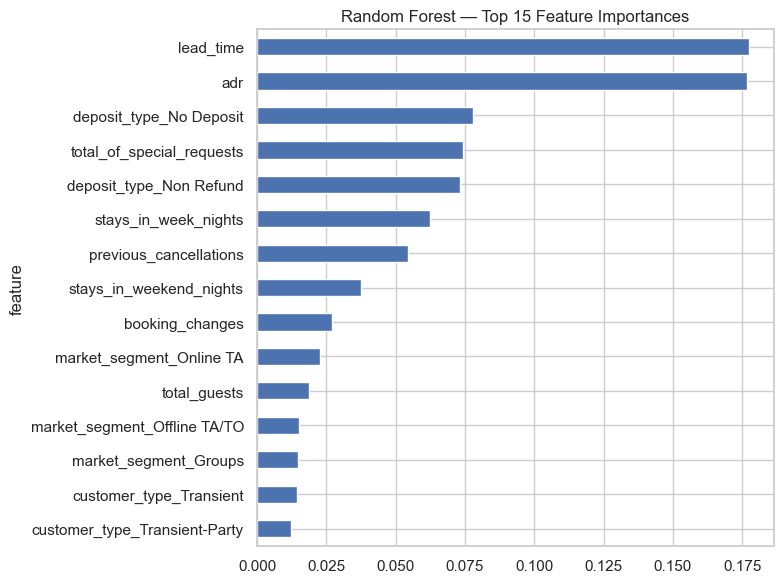

In [30]:
# Feature importance
ohe_features_rf = (rf.named_steps['preprocessor']
                   .named_transformers_['cat']
                   .named_steps['onehot']
                   .get_feature_names_out(categorical_features))

all_features_rf = numeric_features + list(ohe_features_rf)
importances = rf.named_steps['rf'].feature_importances_

imp_df = (pd.DataFrame({'feature': all_features_rf, 'importance': importances})
            .sort_values('importance', ascending=False)
            .head(15))

imp_df.plot(kind='barh', x='feature', y='importance', figsize=(8,6), legend=False)
plt.title('Random Forest — Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## Session 8 — XGBoost

In [31]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc', random_state=42, n_jobs=-1
    ))
])

xgb.fit(X_train, y_train)
y_prob_xgb = xgb.predict_proba(X_val)[:,1]
y_pred_xgb = xgb.predict(X_val)

print("=== XGBoost ===")
print(classification_report(y_val, y_pred_xgb))
print(f"ROC AUC: {roc_auc_score(y_val, y_prob_xgb):.3f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.80      0.87      0.83     15152
           1       0.76      0.66      0.70      9471

    accuracy                           0.79     24623
   macro avg       0.78      0.76      0.77     24623
weighted avg       0.78      0.79      0.78     24623

ROC AUC: 0.858


---
## Session 9 — Threshold Tuning & Final Evaluation

In [32]:
# Find best threshold on val set
precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold (max F1): {best_threshold:.3f}")
print(f"Precision at best: {precisions[best_idx]:.3f}")
print(f"Recall at best:    {recalls[best_idx]:.3f}")
print(f"F1 at best:        {f1_scores[best_idx]:.3f}")

Best threshold (max F1): 0.379
Precision at best: 0.651
Recall at best:    0.780
F1 at best:        0.710


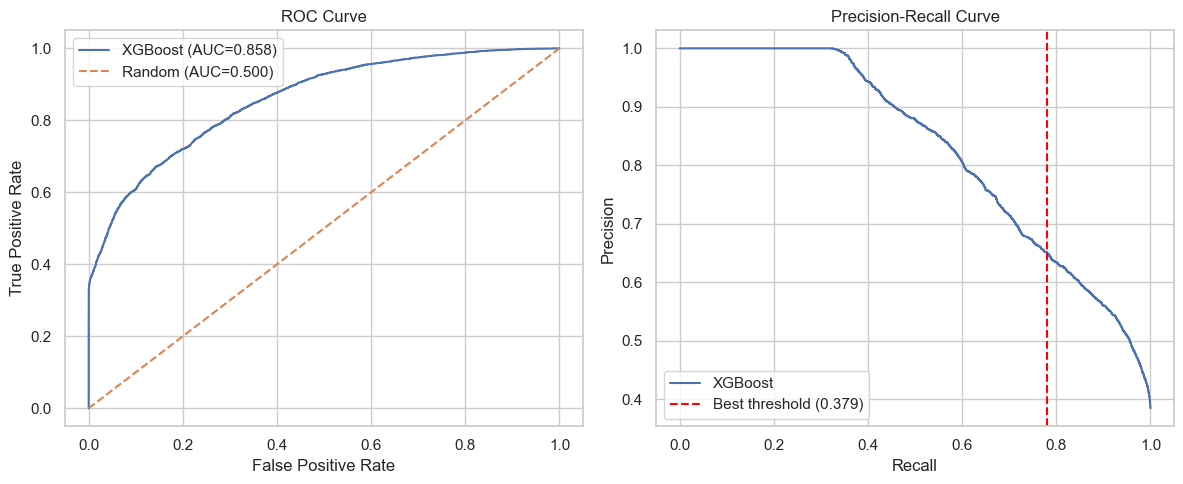

In [33]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_val, y_prob_xgb)
axes[0].plot(fpr, tpr, label=f'XGBoost (AUC={roc_auc_score(y_val, y_prob_xgb):.3f})')
axes[0].plot([0,1],[0,1],'--', label='Random (AUC=0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].plot(recalls, precisions, label='XGBoost')
axes[1].axvline(recalls[best_idx], color='red', linestyle='--', label=f'Best threshold ({best_threshold:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

In [34]:
# FINAL TEST SET EVALUATION — run once, no going back
y_prob_test = xgb.predict_proba(X_test)[:,1]
y_pred_test = (y_prob_test >= best_threshold).astype(int)

print("=== FINAL TEST SET EVALUATION ===")
print(classification_report(y_test, y_pred_test))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_test):.3f}")

=== FINAL TEST SET EVALUATION ===
              precision    recall  f1-score   support

           0       0.82      0.63      0.71      9595
           1       0.58      0.79      0.67      6228

    accuracy                           0.69     15823
   macro avg       0.70      0.71      0.69     15823
weighted avg       0.73      0.69      0.69     15823

ROC AUC: 0.796


### Model Comparison

| Model | Val ROC AUC | Recall (cancelled) |
|---|---|---|
| Majority class | 0.500 | 0% |
| LR — numeric only | 0.730 | 36% |
| LR — full features, balanced | 0.820 | 69% |
| Random Forest | 0.810 | — |
| XGBoost (val, tuned threshold) | 0.835 | 79% |
| **XGBoost — final test** | **0.796** | **79%** |

See [WRITEUP.md](../WRITEUP.md) for full explanation of decisions and lessons.